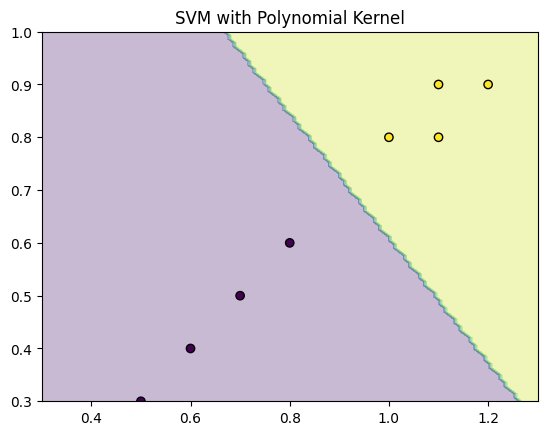

In [2]:
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

# Example 2D dataset (structured but not obvious to the eye)
X = np.array([
    [1.2, 0.9], [1.1, 0.8], [0.7, 0.5], [0.6, 0.4], 
    [1.0, 0.8], [1.1, 0.9], [0.5, 0.3], [0.8, 0.6]
])
y = [1, 1, 0, 0, 1, 1, 0, 0]  # class labels

# Fit an SVM with polynomial kernel
clf = svm.SVC(kernel='poly', degree=3, C=1).fit(X, y)

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(0.3, 1.3, 100),
                     np.linspace(0.3, 1.0, 100))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.title("SVM with Polynomial Kernel")
plt.show()

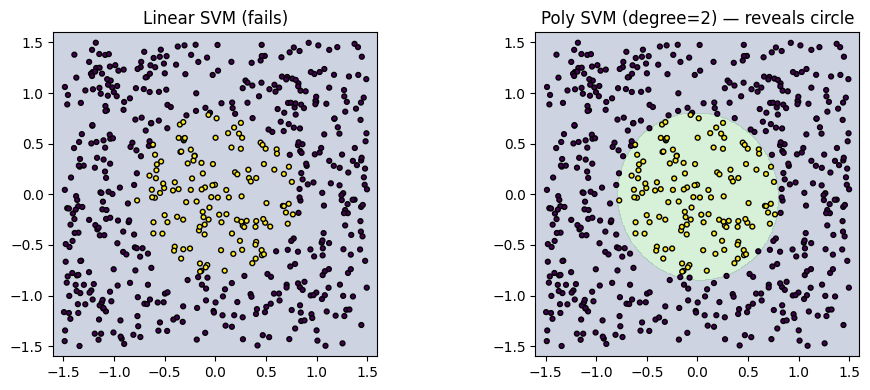

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
# --- synthetic data: points in a square, classes by radius ---
rng = np.random.default_rng(42)
N = 600
X = rng.uniform(-1.5, 1.5, size=(N, 2))
r2 = (X[:,0]**2 + X[:,1]**2)
y = (r2 < 0.8**2).astype(int)  # 1 = inside the circle, 0 = outside

# --- fit linear vs polynomial (degree=2) ---
lin = SVC(kernel="linear", C=1).fit(X, y)
poly = SVC(kernel="poly", degree=2, coef0=1, C=1).fit(X, y)  # quadratic features

# --- plot decision regions ---
def plot_model(ax, clf, title):
    xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 400),
                         np.linspace(-1.6, 1.6, 400))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5])
    ax.scatter(X[:,0], X[:,1], c=y, s=12, edgecolors="k")
    ax.set_title(title)
    ax.set_aspect("equal", "box")

fig, axes = plt.subplots(1, 2, figsize=(10,4))
plot_model(axes[0], lin, "Linear SVM (fails)")
plot_model(axes[1], poly, "Poly SVM (degree=2) — reveals circle")
plt.tight_layout()
plt.show()
